In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/egeakyol/real-estate-in-istanbul-turkey-emlakjet/Real Estate in ISTANBUL (Emlakjet).csv


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/egeakyol/real-estate-in-istanbul-turkey-emlakjet/Real Estate in ISTANBUL (Emlakjet).csv


In [3]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2
import requests
import time
import os
from IPython.display import FileLink

# 1. DATA LOADING
input_path = '/kaggle/input/datasets/egeakyol/real-estate-in-istanbul-turkey-emlakjet/Real Estate in ISTANBUL (Emlakjet).csv'

try:
    df = pd.read_csv(input_path)
    print("Data loaded successfully!")
except FileNotFoundError:
    print("ERROR: File not found.")

df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

yas_map = {'0 (Yeni)':0,'1':1,'2':2,'3':3,'4':4,'5-10':7,'11-15':13,'16-20':18,'21 Ve Üzeri':25}
df['Bina_Yasi_Sayi'] = df['Binanın_Yaşı'].map(yas_map)

def oda_to_sayi(oda):
    try:
        p = str(oda).strip().split('+')
        return int(p[0]) + int(p[1])
    except:
        return np.nan

df['Oda_Sayi_Num'] = df['Oda_Sayısı'].apply(oda_to_sayi)
df['Aykiri_Fiyat'] = ((df['Fiyatı'] > df['Fiyatı'].quantile(0.98)) | (df['Fiyatı'] < df['Fiyatı'].quantile(0.01))).astype(int)

# 2. GEOCODING
HEADERS = {'User-Agent': 'dsa210_istanbul_project/1.2'}
mahalleler = df[['Mahalle', 'İlçe']].drop_duplicates().reset_index(drop=True)
print(f"Geocoding started: {len(mahalleler)} neighborhoods...")

def geocode(mahalle, ilce):
    m_temiz = mahalle.replace("Mahallesi", "").strip()
    for sorgu in [f"{m_temiz}, {ilce}, Istanbul, Turkey", f"{m_temiz}, Istanbul, Turkey"]:
        try:
            r = requests.get('https://nominatim.openstreetmap.org/search',
                            params={'q': sorgu, 'format': 'json', 'limit': 1},
                            headers=HEADERS, timeout=10)
            data = r.json()
            if data:
                return float(data[0]['lat']), float(data[0]['lon'])
        except:
            pass
    return None, None

lats, lons = [], []
for i, row in mahalleler.iterrows():
    lat, lon = geocode(row['Mahalle'], row['İlçe'])
    lats.append(lat); lons.append(lon)
    time.sleep(1.2)
    if (i+1) % 10 == 0:
        print(f"Progress: {i+1}/{len(mahalleler)} done...")

mahalleler['mahalle_lat'] = lats
mahalleler['mahalle_lon'] = lons
mahalleler.to_csv('/kaggle/working/mahalle_koordinatlar.csv', index=False)

# 3. HAVERSINE DISTANCE
df = df.merge(mahalleler[['Mahalle','İlçe','mahalle_lat','mahalle_lon']], on=['Mahalle','İlçe'], how='left')

def haversine(lat1,lon1,lat2,lon2):
    if any(x is None or np.isnan(x) for x in [lat1, lon1, lat2, lon2]): return np.nan
    R=6371; lat1,lon1,lat2,lon2=map(radians,[lat1,lon1,lat2,lon2])
    a=sin((lat2-lat1)/2)**2+cos(lat1)*cos(lat2)*sin((lon2-lon1)/2)**2
    return R*2*atan2(sqrt(a),sqrt(1-a))

istasyonlar = [(41.0058001386,28.881680707),(40.9132883838,29.1923983239),(41.0120083811,28.9480900733),(41.0794660403,28.7672340276),(40.980241915,28.8723322859),(40.9714092752,29.0764726676),(40.8887242519,29.2385281454),(41.0252969925,29.0128155731),(41.0767715513,29.0136915989),(41.0755084748,29.0145271463),(41.0773106797,29.0242490175),(41.0823435461,29.0375407815),(41.0853512482,29.0455710525),(41.0689993628,29.0109240486),(41.0645050502,28.9926737246),(41.0524927818,28.9874152263),(41.0381565458,28.9856591013),(41.0282905337,28.9728491187),(41.022434782,28.9664222621),(41.0122648278,28.9598347809),(41.0055856644,28.9514201471),(41.0050201028,28.950826891),(41.0135844923,28.9771245143),(41.0256996122,29.0135223765),(41.0000768042,29.0301236137),(40.9909023378,29.0376279459),(40.9904063985,29.0219549908),(41.0000996226,29.0303161782),(41.0022997833,29.0445867059),(40.9981735143,29.0598854733),(40.9940461002,29.0707261384),(40.9847287608,29.0903877924),(40.9752225,29.0996930943),(40.9645784145,29.1053503103),(40.9490497377,29.121853858),(40.9358193379,29.1395599592),(40.9299434238,29.147007915),(40.9238194899,29.1546230461),(40.9208832243,29.1663490467),(40.8985880196,29.178771727),(40.9066447114,29.2113837621),(40.882088389,29.2488374197),(40.9065447646,29.3114239088),(41.0282537069,29.028844655),(41.0219145673,29.0364140056),(41.021954492,29.0482914336),(41.0221826659,29.0620828309),(41.0163439849,29.076243829),(41.0246243207,29.0847807184),(41.0259432808,29.0973186221),(41.0241552372,29.108777832),(41.0215409985,29.1183812217),(41.0197169944,29.1304702884),(41.0165423463,29.1405619719),(41.0159627424,29.1515186058),(41.0152668658,29.1623536613),(41.0160785116,29.1792056992),(41.0145632479,29.189207926),(41.0549034307,28.8315007416),(41.0628471179,28.8553800128),(41.0568370074,28.848131392),(41.0714904542,28.8669783971),(41.0811903035,28.8750662124),(41.0838545405,28.8926872572),(41.0823042034,28.9183127582),(41.0796856699,28.9281017456),(41.0802283123,28.9362253204),(41.0791146521,28.9496326544),(41.0795639497,28.9733006431),(41.0797649097,28.9635421453),(41.0706569134,28.9804834482),(41.0619944468,29.0074130115),(41.054110438,29.0096778157),(41.0853738983,28.9083979482),(41.0801645224,28.9763643256),(41.1212997004,28.9468463059),(41.1591296952,28.910227377),(41.1769563911,28.8836670921),(41.0327712121,28.8424316868),(41.0548941972,28.8305389157),(41.0649978935,28.8259631805),(41.0724316434,28.8023325524),(41.0811835113,28.797408964),(41.0403554341,28.8359418382),(41.097668849,28.7912865195),(41.1075881712,28.8014808953),(41.103310128,28.7778792943),(41.1133556519,28.7904528718),(41.1073954459,28.7678710416),(41.1195507427,28.7665088663),(41.0882009753,28.7965144472),(41.058395086,28.7993743238),(41.0342600076,28.9925196278),(41.0314532963,28.9894418022),(41.0221147392,28.9746879491),(41.0174751806,28.9732136953),(41.0151787938,28.9758940742),(41.0121629659,28.9784244836),(41.008087187,28.975587398),(41.0084351413,28.9711299487),(41.0090671307,28.9666983534),(41.0095852413,28.9597904528),(41.0095921116,28.9538638023),(41.0099969873,28.94712091),(41.0123552716,28.9391494468),(41.0107080395,28.9442967061),(41.0158815142,28.9320311155),(41.0159539922,28.9115778282),(41.0192277354,28.9194509655),(41.0182643876,28.9271565618),(41.0078444838,28.9093460025),(41.0115575409,28.8807589097),(41.0152086456,28.8775129878),(41.0173348574,28.8710345188),(41.0289932752,28.8609536978),(41.0330845374,28.8606511837),(41.0209671886,28.8670836783),(41.0103904554,28.9095053582),(41.004213274,28.9075169292),(41.00148356,28.8902959262),(41.0238202101,28.8636557132),(41.0269906403,28.9808666),(41.0182506722,28.9700504844),(41.0209082584,28.9633072364),(41.0242383795,28.9603097439),(41.0286247834,28.9544622861),(41.0340557692,28.9480367019),(41.03956207,28.9439490435),(41.0455174821,28.9379603124),(41.0504706073,28.9351655775),(41.056729923,28.9411189488),(41.0647767596,28.9428944835),(41.0698014663,28.9428477215),(41.0737690827,28.9460604337),(41.0784579664,28.9494471692),(41.0868880935,28.9439170961),(41.0178236153,28.7663997635),(41.0062619961,28.7739273174),(40.9885240376,28.7729423261),(40.9677662609,28.7970279467),(40.9729608799,28.7874733117),(40.962652581,28.8248930566),(40.9654691979,28.8372751097),(40.9802159969,28.8562244497),(40.9817327416,28.8810549364),(40.9926862409,28.9168778133),(40.985877775,28.9054442225),(40.978696151,29.0490084627),(40.9791648388,29.0625591735),(40.9604752408,29.0844186912),(40.9538001485,29.0950591486),(40.9462573976,29.1068216034),(40.9206463836,29.1335259971),(40.9268299859,29.1242047148),(40.9378068715,29.114255858),(40.8985880196,29.1694542075),(40.9100151225,29.1560454699),(40.8886128832,29.191190141),(40.8845046267,29.2105353314),(40.8802067715,29.2316720558),(40.8713029434,29.2560336339),(40.8568547122,29.2834955975),(40.8609774864,29.2733636214),(40.8522885877,29.2931664015),(40.8456508905,29.3000611747),(40.829952436,29.3223601331),(40.9509636456,29.0977225047),(40.9605472642,29.0937084923),(40.9667774717,29.0867181509),(40.9775015583,29.0999002371),(40.9789184865,29.1117414468),(40.9789845394,29.126424906),(40.9846900159,29.1377306108),(41.0001481272,29.1562117564),(40.992156465,29.1533571204),(41.0071876376,29.161855314),(41.0226344203,29.1595514004),(41.0312433529,29.1526674022),(41.0152325915,29.1632870725)]

df['rayli_mesafe_km'] = df.apply(
    lambda r: min(haversine(r['mahalle_lat'],r['mahalle_lon'],s[0],s[1]) for s in istasyonlar)
    if pd.notna(r['mahalle_lat']) else np.nan, axis=1)

df['mesafe_band'] = pd.cut(df['rayli_mesafe_km'], bins=[0,0.5,1,2,3,5,100],
    labels=['0-500m','500m-1km','1-2km','2-3km','3-5km','5km+'])

# 4. SAVE
output_name = '/kaggle/working/istanbul_housing_enriched.csv'
df.to_csv(output_name, index=False, encoding='utf-8-sig')
print(f"\nDone! File saved as '{output_name}'.")
FileLink(output_name)

Data loaded successfully!
Geocoding started: 230 neighborhoods...
Progress: 10/230 done...
Progress: 20/230 done...
Progress: 30/230 done...
Progress: 40/230 done...
Progress: 50/230 done...
Progress: 60/230 done...
Progress: 70/230 done...
Progress: 80/230 done...
Progress: 90/230 done...
Progress: 100/230 done...
Progress: 110/230 done...
Progress: 120/230 done...
Progress: 130/230 done...
Progress: 140/230 done...
Progress: 150/230 done...
Progress: 160/230 done...
Progress: 170/230 done...
Progress: 180/230 done...
Progress: 190/230 done...
Progress: 200/230 done...
Progress: 210/230 done...
Progress: 220/230 done...
Progress: 230/230 done...

Done! File saved as '/kaggle/working/istanbul_housing_enriched.csv'.


/kaggle/working/istanbul_housing_enriched.csv

Train: 2256, Test: 565
Linear Regression: R²=0.3394, RMSE=2.86M TL
Random Forest: R²=0.5547, RMSE=2.34M TL
Gradient Boosting: R²=0.5671, RMSE=2.31M TL


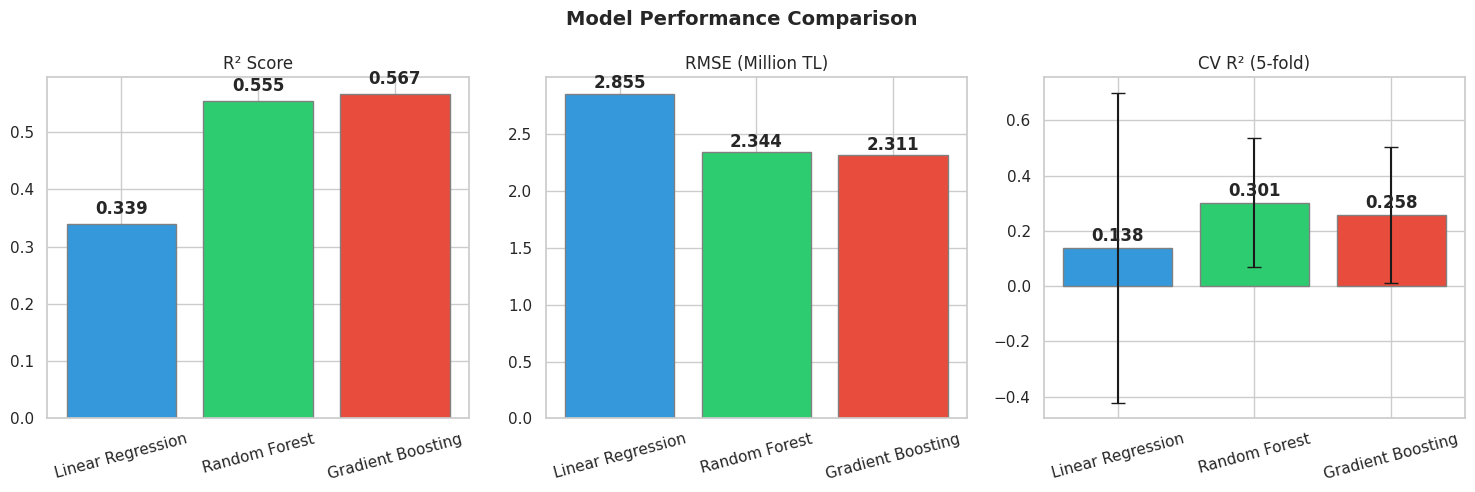

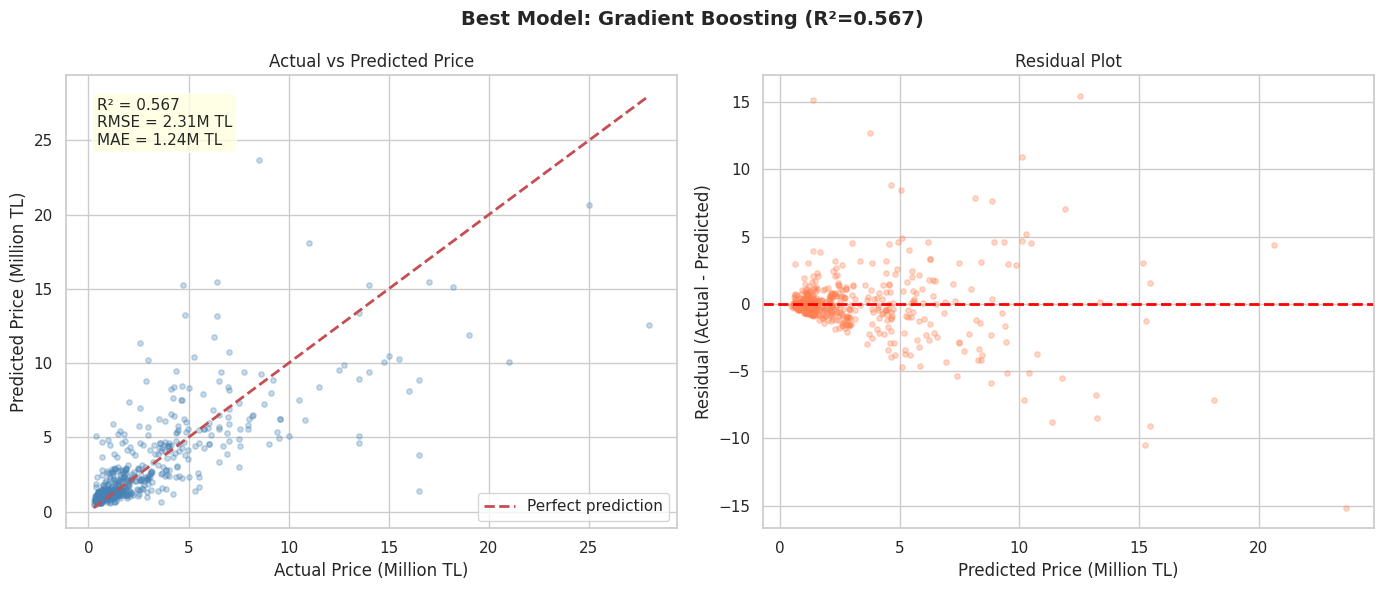

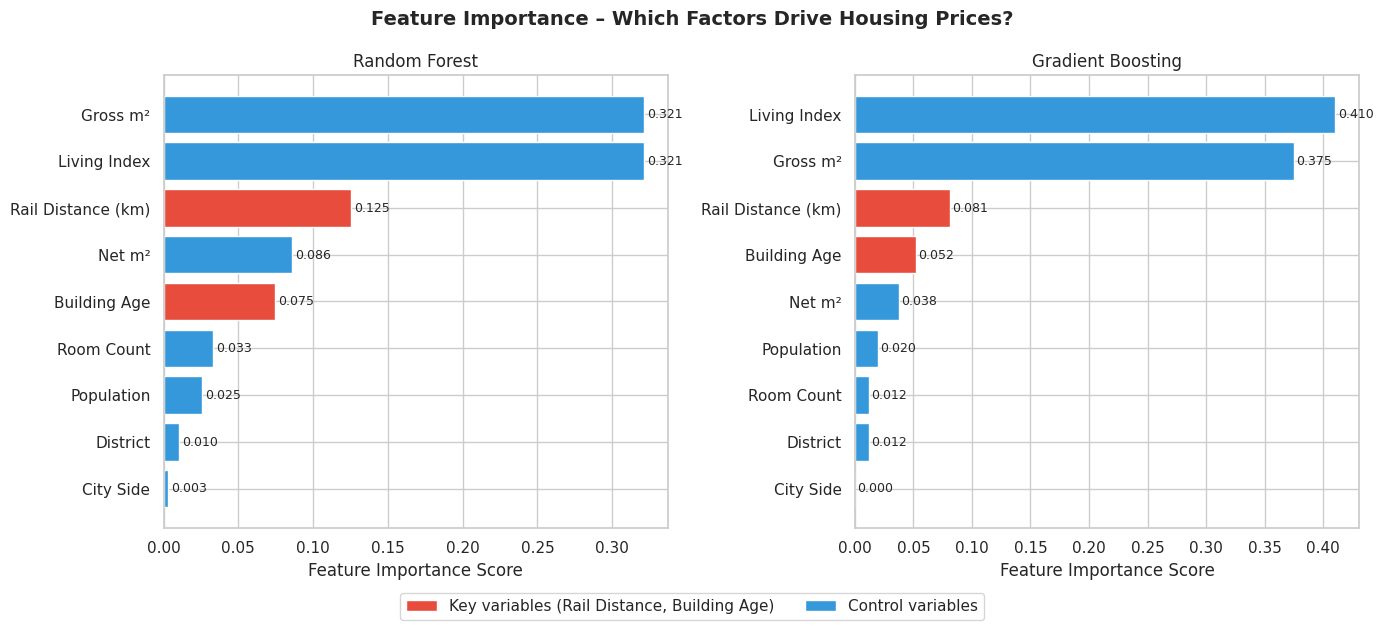


=== FEATURE IMPORTANCE (Random Forest) ===
           Feature  Importance
          Gross m²    0.321359
      Living Index    0.321282
Rail Distance (km)    0.125246
            Net m²    0.086147
      Building Age    0.074552
        Room Count    0.032840
        Population    0.025476
          District    0.010282
         City Side    0.002816

Best model: Gradient Boosting, R²=0.5671, RMSE=2.31M TL


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")

df = pd.read_csv('/kaggle/working/istanbul_housing_enriched.csv')
esik = df['Fiyatı'].quantile(0.98)
df = df[df['Fiyatı'] <= esik].copy()

le = LabelEncoder()
df['ilce_enc'] = le.fit_transform(df['İlçe'].str.strip())
df['yaka_enc'] = le.fit_transform(df['yaka'].str.strip())

feature_cols = ['Bina_Yasi_Sayi', 'rayli_mesafe_km', 'Brüt_Metrekare',
                'Net_Metrekare', 'Yaşam_endeksi', 'Nüfus',
                'yaka_enc', 'ilce_enc', 'Oda_Sayi_Num']

feature_names = {
    'Bina_Yasi_Sayi': 'Building Age',
    'rayli_mesafe_km': 'Rail Distance (km)',
    'Brüt_Metrekare': 'Gross m²',
    'Net_Metrekare': 'Net m²',
    'Yaşam_endeksi': 'Living Index',
    'Nüfus': 'Population',
    'yaka_enc': 'City Side',
    'ilce_enc': 'District',
    'Oda_Sayi_Num': 'Room Count'
}

df_ml = df.dropna(subset=feature_cols + ['Fiyatı']).copy()
X = df_ml[feature_cols]
y = df_ml['Fiyatı'] / 1e6

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    results[name] = {
        'model': model, 'y_pred': y_pred,
        'r2': r2_score(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'mae': mean_absolute_error(y_test, y_pred),
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()
    }
    print(f"{name}: R²={results[name]['r2']:.4f}, RMSE={results[name]['rmse']:.2f}M TL")

# FIGURE 1: Model Comparison
model_names = list(results.keys())
colors = ['#3498db', '#2ecc71', '#e74c3c']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
for ax, metric, title in zip(axes, ['r2', 'rmse', 'cv_mean'], ['R² Score', 'RMSE (Million TL)', 'CV R² (5-fold)']):
    values = [results[n][metric] for n in model_names]
    stds = [results[n]['cv_std'] if metric == 'cv_mean' else 0 for n in model_names]
    bars = ax.bar(model_names, values, color=colors, edgecolor='gray',
                  yerr=stds if metric == 'cv_mean' else None, capsize=5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('/kaggle/working/ml_model_comparison.png', bbox_inches='tight')
plt.show()

# FIGURE 2: Actual vs Predicted
best_name = max(results, key=lambda x: results[x]['r2'])
best = results[best_name]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Best Model: {best_name} (R²={best["r2"]:.3f})', fontsize=14, fontweight='bold')
axes[0].scatter(y_test, best['y_pred'], alpha=0.3, s=15, color='steelblue')
lims = [min(y_test.min(), best['y_pred'].min()), max(y_test.max(), best['y_pred'].max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title('Actual vs Predicted Price')
axes[0].set_xlabel('Actual Price (Million TL)')
axes[0].set_ylabel('Predicted Price (Million TL)')
axes[0].legend()
axes[0].text(0.05, 0.95, f'R² = {best["r2"]:.3f}\nRMSE = {best["rmse"]:.2f}M TL\nMAE = {best["mae"]:.2f}M TL',
             transform=axes[0].transAxes, va='top', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
residuals = y_test.values - best['y_pred']
axes[1].scatter(best['y_pred'], residuals, alpha=0.3, s=15, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Price (Million TL)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.savefig('/kaggle/working/ml_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

# FIGURE 3: Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Importance – Which Factors Drive Housing Prices?', fontsize=14, fontweight='bold')
for ax, model_key in zip(axes, ['Random Forest', 'Gradient Boosting']):
    m = results[model_key]['model']
    imp = pd.DataFrame({
        'feature': [feature_names[f] for f in feature_cols],
        'importance': m.feature_importances_
    }).sort_values('importance', ascending=True)
    bar_colors = ['#e74c3c' if f in ['Rail Distance (km)', 'Building Age'] else '#3498db' for f in imp['feature']]
    bars = ax.barh(imp['feature'], imp['importance'], color=bar_colors)
    ax.set_title(model_key)
    ax.set_xlabel('Feature Importance Score')
    for bar, val in zip(bars, imp['importance']):
        ax.text(val+0.002, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
legend_elements = [
    Patch(facecolor='#e74c3c', label='Key variables (Rail Distance, Building Age)'),
    Patch(facecolor='#3498db', label='Control variables')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig('/kaggle/working/ml_feature_importance.png', bbox_inches='tight')
plt.show()

print("\n=== FEATURE IMPORTANCE (Random Forest) ===")
imp_df = pd.DataFrame({
    'Feature': [feature_names[f] for f in feature_cols],
    'Importance': results['Random Forest']['model'].feature_importances_
}).sort_values('Importance', ascending=False)
print(imp_df.to_string(index=False))
print(f"\nBest model: {best_name}, R²={best['r2']:.4f}, RMSE={best['rmse']:.2f}M TL")